In [1]:
from severity_comparison import *
import pandas as pd
# %matplotlib inline   

## Define the event

In [2]:
model = "gpt-4o"

start_dt = pd.to_datetime('2023-04-01')
months_add, weeks_add, days_add = 0,0,3

end_dt = start_dt + pd.DateOffset(
    months=months_add,
    weeks=weeks_add,
    days=days_add
)


start_re = '2024-08-01'
end_re = '2024-12-20'

past_weeks_window = 2
iso3 = 'SDN'

event_details = {
    "disaster": "civil war, violence",
    "country":  "Sudan",
    "iso2": "SD",
    "iso3": iso3,
    "month": "April",
    "year": 2024,
    "location": "Sudan",
    "start_dt": start_dt.strftime("%Y-%m-%d"),
    "end_dt": end_dt.strftime("%Y-%m-%d"),
    "past_weeks_window": past_weeks_window
}

In [3]:
data_dir = '/eos/jeodpp/home/users/mihadar/data/'

inform_severity_path = os.path.join(data_dir, 'INFORM Severity/Filtered_events.json')
acled_path = os.path.join(data_dir, 'ACLED/ACLED_events_by_country.json')
imdc_path = os.path.join(data_dir, 'IDMC/idmc_organised.json')

## Fetch the data

In [4]:
iso3 = 'PAK'

new_file = extract_country_events(inform_severity_path, iso3, 'ISeverity')
print(f"Saved filtered INFORM SEVERITY file: {new_file}")

# new_file = extract_country_events(acled_path, iso3, 'ACLED')
# print(f"Saved filtered ACLED file: {new_file}")

new_file = extract_country_events(imdc_path, iso3, 'IDMC')
print(f"Saved filtered IDMC file: {new_file}")

Saved filtered INFORM SEVERITY file: /eos/jeodpp/home/users/mihadar/data/for report/PAK/PAK_ISeverity.json
Saved filtered IDMC file: /eos/jeodpp/home/users/mihadar/data/for report/PAK/PAK_IDMC.json


## INFORM Severity

In [5]:
import json
with open('/eos/jeodpp/home/users/mihadar/data/for report/PAK/PAK_ISeverity.json') as f:
    d = json.load(f)

for event_id, inner in d.items():
    print(event_id, repr(inner.get("type_of_crisis")))

PAK001 None
PAK007 None


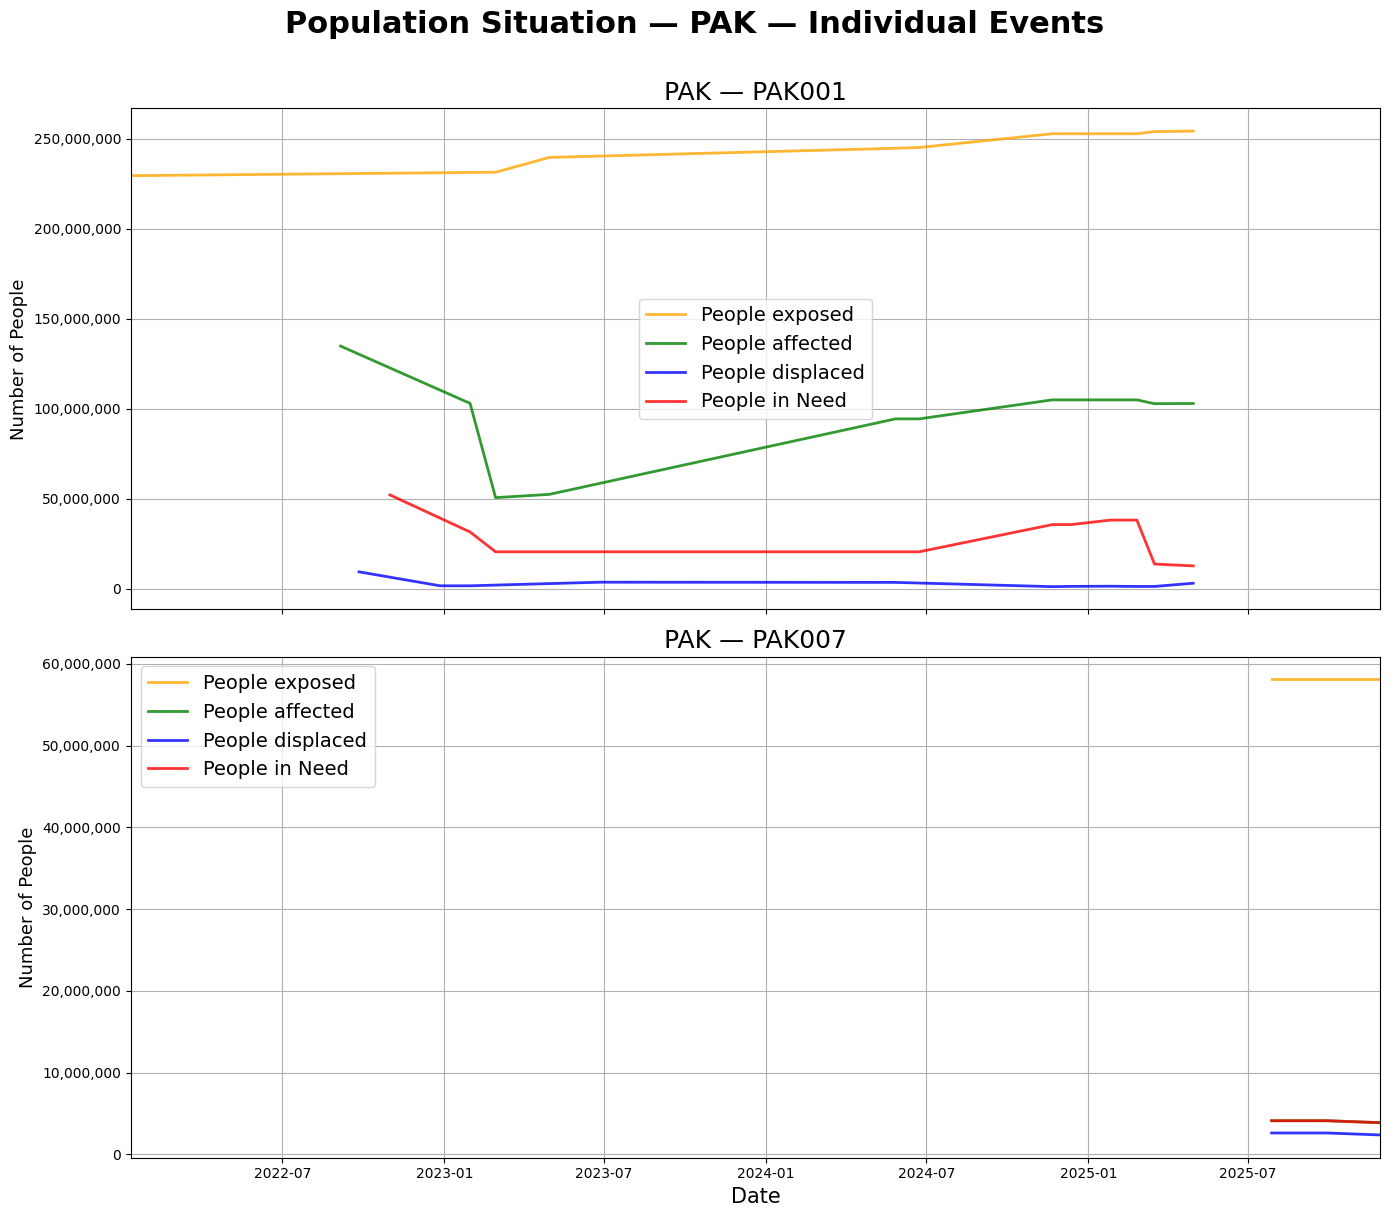

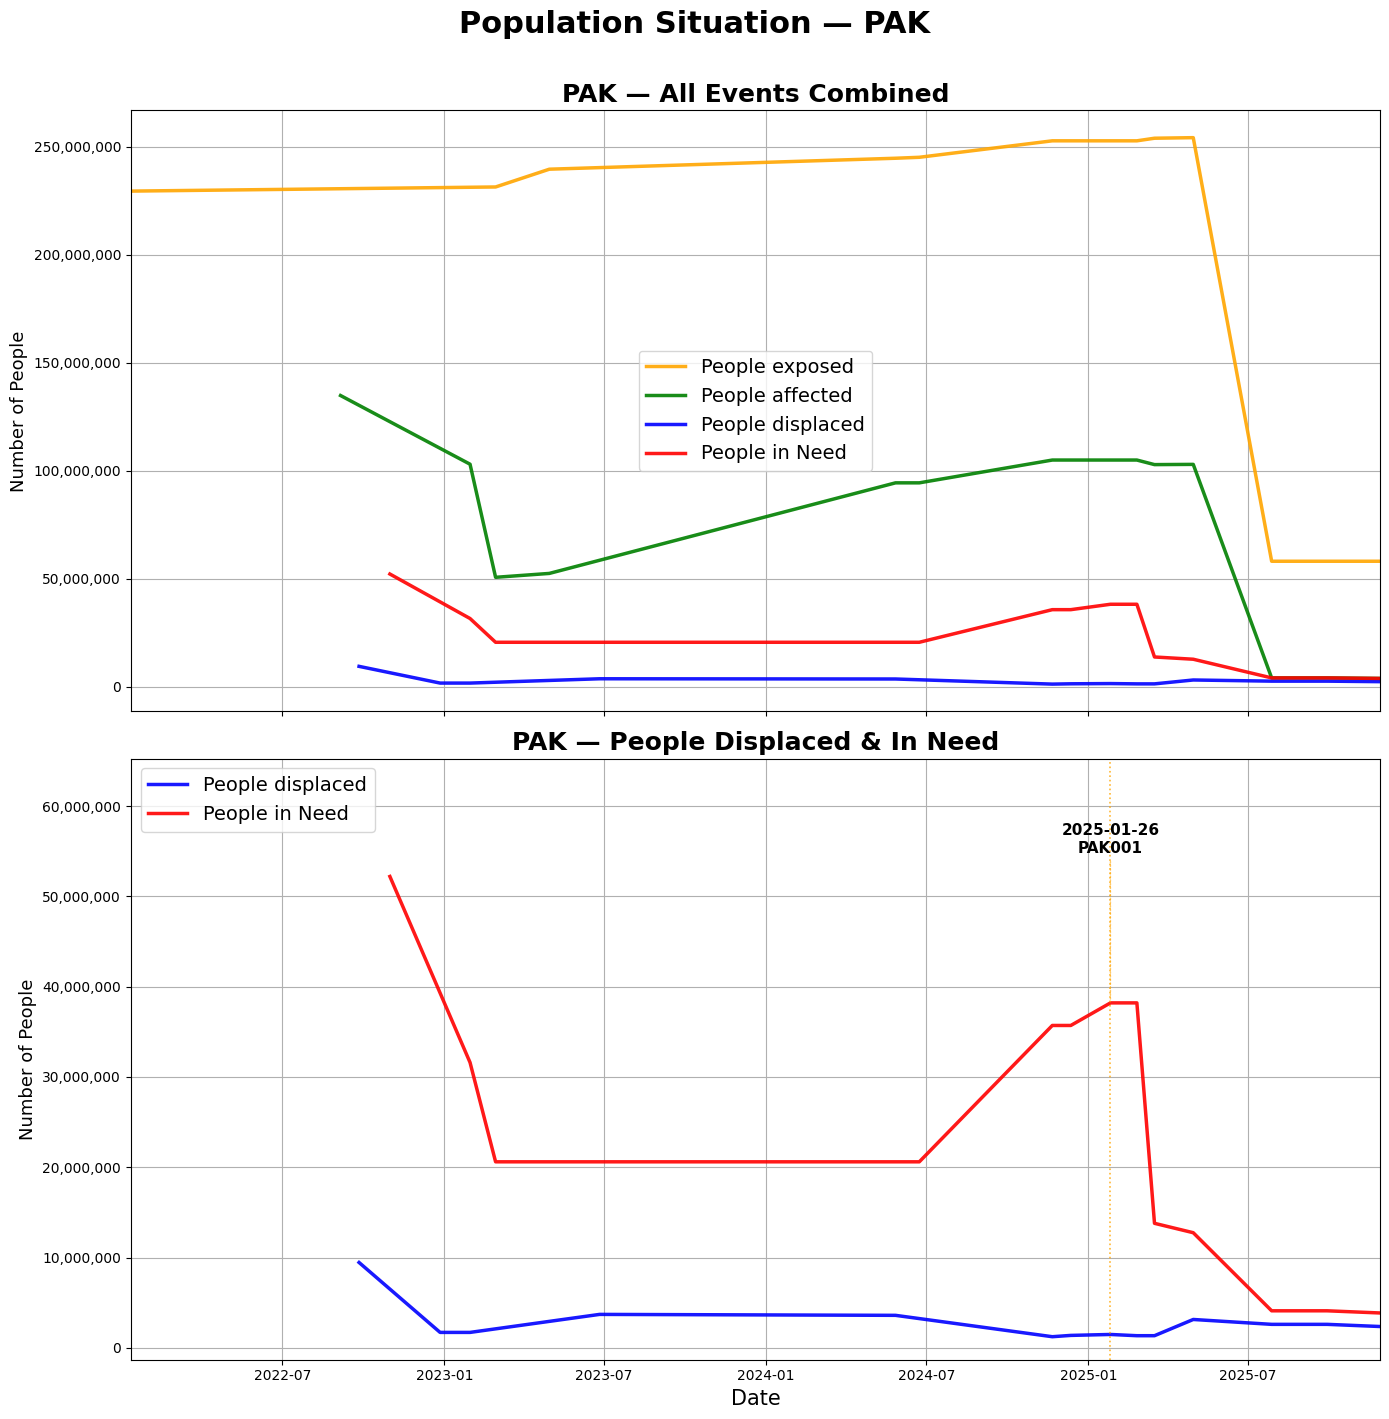

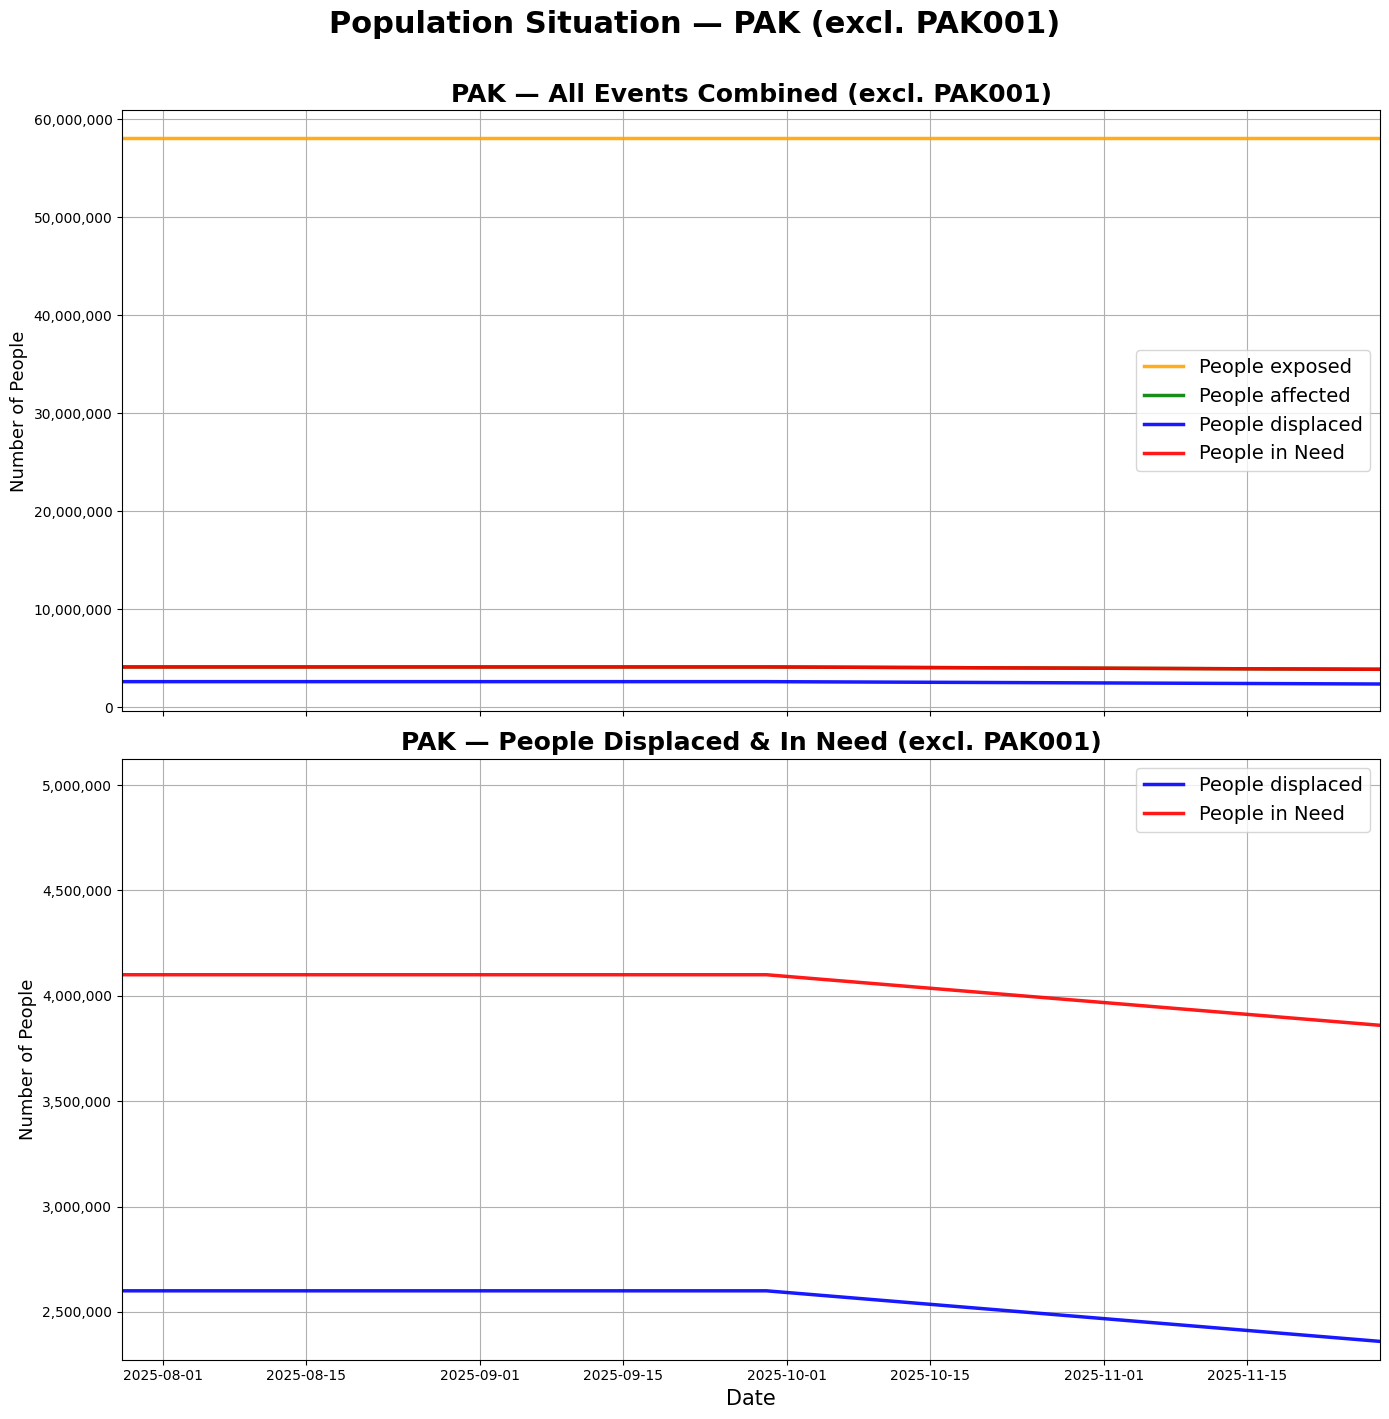

In [6]:
event_data, first_event_id = load_severity(iso3)
fig1, fig2, fig3 = plot_severity(iso3, event_data, first_event_id)

In [7]:
# fig1, fig2, fig3 = plot_severity(iso3)
# plt.show()

## ACLED

In [8]:
# acled_dates, acled_numbers, coordinates_acled, fig = plot_acled_population_filtered(iso3, start_re, end_re)
# plt.show()

# # inspect the raw events
# print(f"Total events: {len(acled_numbers)}")
# # print(filtered_events[0])  

## IDMC

In [9]:
# idmc_dates, idmc_numbers, coordinates_idmc, fig = plot_idmc_filtered(iso3, start_re, end_re)
# plt.show()

# print(f"Total IDMC events: {len(idmc_numbers)}")
# # print(filtered_events[0])

## EMM

## Locations Worldpop INFORM Risk

## Comparison all 

In [10]:
# fig2, fig3 = plot_severity_with_acled_idmc(
#     iso3, event_data, first_event_id,
#     acled_dates, acled_numbers,
#    idmc_dates, idmc_numbers,
#      start_re, end_re
# )
# plt.show()

In [28]:
from datetime import datetime, time
from dateutil.relativedelta import relativedelta
import numpy as np
from collections import defaultdict

def compute_pin_affected_ratio(event_data, date_x):
    """
    Computes the People‑in‑Need / People‑Affected ratio for the 12‑month
    period that ends on *date_x*.

    Parameters
    ----------
    event_data : dict
        As returned by ``load_severity()``. Must contain the ``"SUM"`` key.
    date_x : datetime.datetime or datetime.date
        Reference date. Only values whose date lies in the interval
        [date_x – 1 year, date_x) are taken into account.

    Returns
    -------
    mean_ratio : float
        Average of PIN / People‑Affected across all matched dates.
    std_ratio : float
        Sample standard deviation of those ratios (±1 σ).
    ratios : list of (datetime.date, float)
        Individual ratio points used in the calculation.

    Raises
    ------
    ValueError
        If no dates satisfy the filtering criteria or no overlapping dates
        with a non‑zero People‑Affected value are found.
    """
    # ------------------------------------------------------------------ #
    # 1.  Extract the summed series (same as the original implementation)
    # ------------------------------------------------------------------ #
    sum_entry = event_data["SUM"]
    pin_dict      = dict(sum_entry["People in Need"])
    affected_dict = dict(sum_entry["People affected"])

    # ------------------------------------------------------------------ #
    # 2.  Normalise the reference date to a ``datetime`` at midnight
    # ------------------------------------------------------------------ #
    if isinstance(date_x, datetime):
        ref_dt = date_x.replace(hour=0, minute=0, second=0, microsecond=0)
    else:   # date object
        ref_dt = datetime.combine(date_x, time.min)

    # Exact calendar‑year window (handles 366‑day years)
    start_dt = ref_dt - relativedelta(years=1)   # inclusive lower bound
    end_dt   = ref_dt                           # exclusive upper bound

    # ------------------------------------------------------------------ #
    # 3.  Keep only dates that fall inside the window and exist in both
    #     series.  The dates stored in the dictionaries are ``datetime``.
    # ------------------------------------------------------------------ #
    common_dates = sorted(
        d for d in set(pin_dict.keys()) & set(affected_dict.keys())
        if start_dt <= d < end_dt
    )

    # ------------------------------------------------------------------ #
    # 4.  Compute the ratios, avoiding division by zero
    # ------------------------------------------------------------------ #
    ratios = []
    for d in common_dates:
        affected_val = affected_dict[d]
        pin_val      = pin_dict[d]
        if affected_val > 0:
            ratios.append((d.date(), pin_val / affected_val))   # return a date, not datetime

    if not ratios:
        raise ValueError(
            "No overlapping dates within the one‑year window that have a "
            "non‑zero People‑Affected value."
        )

    # ------------------------------------------------------------------ #
    # 5.  Statistics
    # ------------------------------------------------------------------ #
    ratio_values = np.array([r for _, r in ratios])
    mean_ratio   = float(np.mean(ratio_values))
    std_ratio    = float(np.std(ratio_values, ddof=1))   # sample std‑dev

    # ------------------------------------------------------------------ #
    # 6.  Human‑readable summary (optional)
    # ------------------------------------------------------------------ #
    print(f"PIN / People Affected ratio — {len(ratios)} date points used")
    print(f"  Window : {start_dt.date().isoformat()} → {end_dt.date().isoformat()}")
    print(f"  Mean   : {mean_ratio:.4f}  ({mean_ratio*100:.1f}%)")
    print(f"  ±1σ    : {std_ratio:.4f}  ({std_ratio*100:.1f}%)")
    print(f"  Range  : {ratio_values.min():.4f} – {ratio_values.max():.4f}")
    print("\n  Individual ratios:")
    for d, r in ratios:
        print(f"    {d.isoformat()} → {r:.4f} ({r*100:.1f}%)")

    return mean_ratio, std_ratio, ratios

In [29]:
from datetime import datetime

print('for sudan')

# Load the data for a given ISO‑3 country code (e.g. "FRA")
event_data, _ = load_severity("SDN")

# Choose the reference date – for example 15 May 2024
reference_date = datetime(2024, 10, 4)

# Compute the ratio for the year preceding the reference date
mean, std, points = compute_pin_affected_ratio(event_data, reference_date)

for sudan
PIN / People Affected ratio — 6 date points used
  Window : 2023-10-04 → 2024-10-04
  Mean   : 0.0738  (7.4%)
  ±1σ    : 0.0087  (0.9%)
  Range  : 0.0699 – 0.0915

  Individual ratios:
    2024-04-15 → 0.0915 (9.2%)
    2024-05-31 → 0.0705 (7.1%)
    2024-06-30 → 0.0705 (7.1%)
    2024-07-29 → 0.0705 (7.1%)
    2024-08-26 → 0.0699 (7.0%)
    2024-09-25 → 0.0699 (7.0%)


In [30]:
print('for syria')

# Load the data for a given ISO‑3 country code (e.g. "FRA")
event_data, _ = load_severity("SYR")

# Choose the reference date – for example 15 May 2024
reference_date = datetime(2024, 12, 8)

# Compute the ratio for the year preceding the reference date
mean, std, points = compute_pin_affected_ratio(event_data, reference_date)

for syria
PIN / People Affected ratio — 1 date points used
  Window : 2023-12-08 → 2024-12-08
  Mean   : 0.7102  (71.0%)
  ±1σ    : nan  (nan%)
  Range  : 0.7102 – 0.7102

  Individual ratios:
    2024-04-19 → 0.7102 (71.0%)


/home/mihadar/.local/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/mihadar/.local/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [31]:
print('for pakistan')

# Load the data for a given ISO‑3 country code (e.g. "FRA")
event_data, _ = load_severity("PAK")

# Choose the reference date – for example 15 May 2024
reference_date = datetime(2025, 11, 16)

# Compute the ratio for the year preceding the reference date
mean, std, points = compute_pin_affected_ratio(event_data, reference_date)

for pakistan
PIN / People Affected ratio — 9 date points used
  Window : 2024-11-16 → 2025-11-16
  Mean   : 0.5184  (51.8%)
  ±1σ    : 0.3726  (37.3%)
  Range  : 0.1238 – 1.0000

  Individual ratios:
    2024-11-21 → 0.3401 (34.0%)
    2024-12-12 → 0.3401 (34.0%)
    2025-01-26 → 0.3639 (36.4%)
    2025-02-25 → 0.3639 (36.4%)
    2025-03-17 → 0.1341 (13.4%)
    2025-04-30 → 0.1238 (12.4%)
    2025-07-28 → 1.0000 (100.0%)
    2025-08-21 → 1.0000 (100.0%)
    2025-09-29 → 1.0000 (100.0%)
